In [ ]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Running in Google Colab — Drive mounted.')
else:
    print('Running locally (VS Code / Jupyter).')


In [ ]:
import torch, sys
print(f'Python:     {sys.version.split()[0]}')
print(f'PyTorch:    {torch.__version__}')
print(f'CUDA avail: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name:   {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU — running on CPU.')
    print('Switch to a GPU runtime before continuing.')


Python:     3.12.13
PyTorch:    2.10.0+cu128
CUDA avail: True
GPU name:   Tesla T4
GPU memory: 15.6 GB


## 1. Imports

In [ ]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from PIL import Image

print('All imports OK.')

All imports OK.


## 2. Configuration & Paths

In [ ]:
if IN_COLAB:
    _DB_ROOT     = '/content/drive/MyDrive/XAI-Project/DB'
    DRIVE_ROOT   = f'{_DB_ROOT}/DB1'
    DATASET_DIR  = f'{DRIVE_ROOT}/CUB_200_2011/'
    ATTR_TXT     = f'{DRIVE_ROOT}/attributes.txt'
    HCBM_CKPT    = f'{DRIVE_ROOT}/best_model.pth'
    B1_CKPT      = f'{DRIVE_ROOT}/baseline_rn50.pth'
    B2_CKPT      = f'{DRIVE_ROOT}/baseline_flat_cbm.pth'
    HISTORY_PATH = f'{DRIVE_ROOT}/train_history.pkl'
else:
    _ROOT        = os.path.abspath('.')
    DRIVE_ROOT   = _ROOT
    DATASET_DIR  = os.path.join(_ROOT, 'DB', 'DB1', 'CUB_200_2011', '')
    ATTR_TXT     = os.path.join(_ROOT, 'DB', 'DB1', 'attributes.txt')
    HCBM_CKPT    = os.path.join(_ROOT, 'best_model.pth')
    B1_CKPT      = os.path.join(_ROOT, 'baseline_rn50.pth')
    B2_CKPT      = os.path.join(_ROOT, 'baseline_flat_cbm.pth')
    HISTORY_PATH = os.path.join(_ROOT, 'train_history.pkl')

BATCH_SIZE = 32
IMG_SIZE   = 224

print(f'DATASET_DIR : {DATASET_DIR}')
print(f'HCBM_CKPT   : {HCBM_CKPT}')
print(f'B1_CKPT     : {B1_CKPT}')
print(f'B2_CKPT     : {B2_CKPT}')


DATASET_DIR : /content/drive/MyDrive/XAI-Project/DB/DB1/CUB_200_2011/
HCBM_CKPT   : /content/drive/MyDrive/XAI-Project/DB/DB1/best_model.pth
B1_CKPT     : /content/drive/MyDrive/XAI-Project/DB/DB1/baseline_rn50.pth
B2_CKPT     : /content/drive/MyDrive/XAI-Project/DB/DB1/baseline_flat_cbm.pth


## 3. Load CUB Data

Same pipeline as `train.ipynb` — required for DataLoaders and concept intervention.

In [ ]:
with open(os.path.join(DATASET_DIR, 'images.txt')) as f:
    image_list = [line.strip().split(' ', 1)[1] for line in f]

with open(os.path.join(DATASET_DIR, 'image_class_labels.txt')) as f:
    labels = [int(line.strip().split()[1]) for line in f]

with open(ATTR_TXT) as f:
    attr_names = [line.strip().split(' ', 1)[1] for line in f]

attr_label_txt = os.path.join(DATASET_DIR, 'attributes', 'image_attribute_labels.txt')
image_attr           = {}
image_attr_certainty = {}

with open(attr_label_txt) as f:
    for line in f:
        parts     = line.strip().split()
        img_id    = int(parts[0])
        attr_id   = int(parts[1]) - 1
        present   = int(parts[2])
        cert      = int(parts[3])
        image_attr.setdefault(img_id, {})[attr_id] = present
        image_attr_certainty.setdefault(img_id, {})[attr_id] = cert

num_attrs = len(attr_names)
attr_vectors    = []
certainty_masks = []
for i in range(1, len(image_list) + 1):
    vec  = np.zeros(num_attrs, dtype=np.int8)
    cert = np.zeros(num_attrs, dtype=np.int8)
    for attr_id, is_present in image_attr.get(i, {}).items():
        vec[attr_id]  = is_present
        cert[attr_id] = 1 if image_attr_certainty.get(i, {}).get(attr_id, 0) >= 3 else 0
    attr_vectors.append(vec)
    certainty_masks.append(cert)

print(f'Images: {len(image_list)}, Attributes: {num_attrs}')

Images: 11788, Attributes: 312


In [ ]:
MERGE_MAP = {'under_tail':'tail','upper_tail':'tail','upperparts':'back','underparts':'belly'}
NO_PARENT = {'primary', 'shape', 'size'}

part_to_attr_indices = {}
attr_to_part         = {}

for idx, name in enumerate(attr_names):
    category = name.split('::')[0].replace('has_', '')
    for suffix in ('_color', '_pattern', '_shape', '_length'):
        if category.endswith(suffix):
            part = category[:-len(suffix)]
            break
    else:
        part = category
    part = MERGE_MAP.get(part, part)
    if part in NO_PARENT:
        attr_to_part[idx] = None
        continue
    attr_to_part[idx] = part
    part_to_attr_indices.setdefault(part, []).append(idx)

CONCEPT_NAMES = sorted(part_to_attr_indices.keys())
NUM_L1        = len(CONCEPT_NAMES)
NUM_L2        = num_attrs
part_to_idx   = {p: i for i, p in enumerate(CONCEPT_NAMES)}

attr_parent_idx = np.array(
    [part_to_idx[attr_to_part[i]] if attr_to_part.get(i) is not None else -1
     for i in range(NUM_L2)], dtype=np.int32
)

CUB_PART_TO_L1 = {
    1:'back', 2:'bill', 3:'belly', 4:'breast',
    5:'crown', 6:'forehead', 7:'eye', 8:'leg',
    9:'wing', 10:'nape', 11:'eye', 12:'leg',
    13:'wing', 14:'tail', 15:'throat',
}
image_part_visible = {}
with open(os.path.join(DATASET_DIR, 'parts', 'part_locs.txt')) as f:
    for line in f:
        cols        = line.strip().split()
        img_id      = int(cols[0])
        cub_part_id = int(cols[1])
        visible     = int(cols[4])
        l1_part     = CUB_PART_TO_L1.get(cub_part_id)
        if l1_part and l1_part in part_to_idx:
            l1_idx = part_to_idx[l1_part]
            image_part_visible.setdefault(img_id, {})
            image_part_visible[img_id][l1_idx] = max(
                image_part_visible[img_id].get(l1_idx, 0), visible
            )
if 'head' in part_to_idx:
    head_idx = part_to_idx['head']
    sub_idxs = [part_to_idx[s] for s in ['crown','forehead','eye','nape'] if s in part_to_idx]
    for img_id in image_part_visible:
        image_part_visible[img_id][head_idx] = max(
            image_part_visible[img_id].get(si, 0) for si in sub_idxs
        )

print(f'NUM_L1={NUM_L1}, NUM_L2={NUM_L2}, CONCEPT_NAMES={CONCEPT_NAMES}')

NUM_L1=13, NUM_L2=312, CONCEPT_NAMES=['back', 'belly', 'bill', 'breast', 'crown', 'eye', 'forehead', 'head', 'leg', 'nape', 'tail', 'throat', 'wing']


In [ ]:
with open(os.path.join(DATASET_DIR, 'train_test_split.txt')) as f:
    is_train = [int(line.strip().split()[1]) for line in f]

image_ids = list(range(1, len(image_list) + 1))

all_train_images = [img for img, t in zip(image_list,      is_train) if t == 1]
all_train_labels = [lbl for lbl, t in zip(labels,          is_train) if t == 1]
all_train_attrs  = [vec for vec, t in zip(attr_vectors,    is_train) if t == 1]
all_train_certs  = [c   for c,   t in zip(certainty_masks, is_train) if t == 1]
all_train_ids    = [iid for iid, t in zip(image_ids,       is_train) if t == 1]

test_images = [img for img, t in zip(image_list,      is_train) if t == 0]
test_labels = [lbl for lbl, t in zip(labels,          is_train) if t == 0]
test_attrs  = [vec for vec, t in zip(attr_vectors,    is_train) if t == 0]
test_certs  = [c   for c,   t in zip(certainty_masks, is_train) if t == 0]
test_ids    = [iid for iid, t in zip(image_ids,       is_train) if t == 0]

indices = list(range(len(all_train_images)))
train_idx, val_idx = train_test_split(
    indices, test_size=0.1, random_state=42, stratify=all_train_labels
)
train_images = [all_train_images[i] for i in train_idx]
train_labels = [all_train_labels[i] for i in train_idx]
train_attrs  = [all_train_attrs[i]  for i in train_idx]
train_certs  = [all_train_certs[i]  for i in train_idx]
train_ids    = [all_train_ids[i]    for i in train_idx]

val_images = [all_train_images[i] for i in val_idx]
val_labels = [all_train_labels[i] for i in val_idx]
val_attrs  = [all_train_attrs[i]  for i in val_idx]
val_certs  = [all_train_certs[i]  for i in val_idx]
val_ids    = [all_train_ids[i]    for i in val_idx]

def build_l1_labels(attr_vecs):
    result = np.zeros((len(attr_vecs), NUM_L1), dtype=np.float32)
    for i, vec in enumerate(attr_vecs):
        for part, idxs in part_to_attr_indices.items():
            if any(vec[j] for j in idxs):
                result[i, part_to_idx[part]] = 1.0
    return result

def build_visibility(img_id_list):
    result = np.zeros((len(img_id_list), NUM_L1), dtype=np.float32)
    for i, iid in enumerate(img_id_list):
        for l1_idx, v in image_part_visible.get(iid, {}).items():
            result[i, l1_idx] = float(v)
    return result

train_l1 = build_l1_labels(train_attrs);  train_l2 = np.array(train_attrs, dtype=np.float32)
train_cm = np.array(train_certs, dtype=np.float32);  train_vis = build_visibility(train_ids)
val_l1   = build_l1_labels(val_attrs);    val_l2   = np.array(val_attrs,   dtype=np.float32)
val_cm   = np.array(val_certs, dtype=np.float32);    val_vis   = build_visibility(val_ids)
test_l1  = build_l1_labels(test_attrs);   test_l2  = np.array(test_attrs,  dtype=np.float32)
test_cm  = np.array(test_certs, dtype=np.float32);   test_vis  = build_visibility(test_ids)

print(f'Train {len(train_images)} | Val {len(val_images)} | Test {len(test_images)}')

Train 5394 | Val 600 | Test 5794


In [ ]:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class BirdDataset(Dataset):
    def __init__(self, image_paths, labels, l1_labels, l2_labels,
                 certainty_mask, visibility, img_root, transform=None):
        self.paths = image_paths;  self.labels = labels
        self.l1 = l1_labels;       self.l2 = l2_labels
        self.cert = certainty_mask; self.vis = visibility
        self.img_root = img_root;  self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_root, 'images', self.paths[idx])).convert('RGB')
        if self.transform: img = self.transform(img)
        label = torch.tensor(self.labels[idx] - 1, dtype=torch.long)
        return (img, label,
                torch.tensor(self.l1[idx],   dtype=torch.float32),
                torch.tensor(self.l2[idx],   dtype=torch.float32),
                torch.tensor(self.cert[idx], dtype=torch.float32),
                torch.tensor(self.vis[idx],  dtype=torch.float32))

pin_memory = torch.cuda.is_available()

test_dataset  = BirdDataset(test_images, test_labels, test_l1, test_l2,
                            test_cm, test_vis, DATASET_DIR, eval_transform)
val_dataset   = BirdDataset(val_images, val_labels, val_l1, val_l2,
                            val_cm, val_vis, DATASET_DIR, eval_transform)
train_dataset = BirdDataset(train_images, train_labels, train_l1, train_l2,
                            train_cm, train_vis, DATASET_DIR, train_transform)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin_memory)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=pin_memory)

print(f'Test batches : {len(test_loader)}')
print(f'Val batches  : {len(val_loader)}')

Test batches : 182
Val batches  : 19


## 4. Load Trained H-CBM

Loads the best checkpoint saved by `train.ipynb`.

In [ ]:
class HierarchicalCBM(nn.Module):
    def __init__(self, attr_parent_idx, num_classes=200, num_l1=13, num_l2=312):
        super().__init__()
        self.register_buffer('attr_parent_idx', torch.tensor(attr_parent_idx, dtype=torch.long))
        backbone      = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.coarse_head = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_l1)
        )
        self.fine_head = nn.Sequential(
            nn.Linear(2048 + num_l1, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_l2)
        )
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        feats   = self.features(x).flatten(1)
        z_c     = self.coarse_head(feats)
        p_c     = torch.sigmoid(z_c)
        z_f     = self.fine_head(torch.cat([feats, p_c], 1))
        p_f_raw = torch.sigmoid(z_f)
        parent_idx   = self.attr_parent_idx
        safe_idx     = parent_idx.clamp(min=0)
        parent_probs = p_c[:, safe_idx]
        has_parent   = (parent_idx >= 0).unsqueeze(0)
        mask         = torch.where(has_parent, parent_probs, torch.ones_like(parent_probs))
        p_f          = p_f_raw * mask
        cls_logits   = self.classifier(p_f)
        return cls_logits, z_c, p_c, z_f, p_f

print('HierarchicalCBM defined.')

HierarchicalCBM defined.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_hcbm  = torch.load(HCBM_CKPT, map_location=device, weights_only=False)
model_hcbm = HierarchicalCBM(attr_parent_idx, num_classes=200, num_l1=NUM_L1, num_l2=NUM_L2).to(device)
model_hcbm.load_state_dict(ckpt_hcbm['model_state_dict'])
model_hcbm.eval()

print(f'H-CBM loaded from epoch {ckpt_hcbm["epoch"]}')
print(f'  Val loss (at checkpoint): {ckpt_hcbm["val_loss"]:.4f}')
print(f'  Val acc  (at checkpoint): {ckpt_hcbm["val_acc"]:.4f}')


H-CBM loaded from epoch 32
  Val loss (at checkpoint): 1.0670
  Val acc  (at checkpoint): 0.7483


## 5. Standard Predictive Performance

Top-1 and Top-5 accuracy on the official CUB test split (5,794 images).

In [ ]:
@torch.no_grad()
def compute_topk(model, loader, device, k=5):
    """Compute Top-1 and Top-k accuracy. Works for any model returning a tuple or tensor."""
    model.eval()
    correct1, correctk, total = 0, 0, 0
    for imgs, labels, *rest in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out      = model(imgs)
        cls_out  = out[0] if isinstance(out, tuple) else out
        top1     = cls_out.argmax(1)
        topk     = cls_out.topk(k, dim=1)[1]
        correct1 += (top1 == labels).sum().item()
        correctk += topk.eq(labels.unsqueeze(1).expand_as(topk)).any(dim=1).sum().item()
        total    += labels.size(0)
    return correct1 / total, correctk / total


hcbm_top1, hcbm_top5 = compute_topk(model_hcbm, test_loader, device)
print(f'H-CBM  Top-1: {hcbm_top1:.4f} ({hcbm_top1*100:.1f}%)')
print(f'H-CBM  Top-5: {hcbm_top5:.4f} ({hcbm_top5*100:.1f}%)')

H-CBM  Top-1: 0.7542 (75.4%)
H-CBM  Top-5: 0.9322 (93.2%)


## 6. Concept Quality Metrics

Evaluate how well the model predicts concepts at both levels:
- **L1 Concept Accuracy** (13 body parts, threshold 0.5)
- **L2 Concept macro-F1** (312 attributes, threshold 0.5)
- **L2 macro-AUROC** (threshold-independent, per-attribute then averaged)

In [ ]:
@torch.no_grad()
def collect_concept_predictions(model, loader, device):
    """Run model on loader and return concept predictions and ground-truth arrays."""
    model.eval()
    p_c_list, p_f_list, l1_list, l2_list = [], [], [], []
    for imgs, labels, l1, l2, cert, vis in loader:
        imgs = imgs.to(device)
        _, z_c, p_c, z_f, p_f = model(imgs)
        p_c_list.append(p_c.cpu().numpy())
        p_f_list.append(p_f.cpu().numpy())
        l1_list.append(l1.numpy())
        l2_list.append(l2.numpy())
    return (np.vstack(p_c_list), np.vstack(p_f_list),
            np.vstack(l1_list),  np.vstack(l2_list))


p_c_arr, p_f_arr, l1_arr, l2_arr = collect_concept_predictions(model_hcbm, test_loader, device)
print(f'Collected: p_c {p_c_arr.shape}, p_f {p_f_arr.shape}')

# ── L1 Concept Accuracy (per part and macro) ──────────────────────────────────
l1_preds    = (p_c_arr > 0.5).astype(int)
l1_acc_part = (l1_preds == l1_arr.astype(int)).mean(axis=0)  # (13,)
l1_acc_macro = l1_acc_part.mean()

print(f'\nL1 Concept Accuracy (per part):')
for name, acc in zip(CONCEPT_NAMES, l1_acc_part):
    print(f'  {name:12s}: {acc:.3f}')
print(f'  Macro average: {l1_acc_macro:.4f} ({l1_acc_macro*100:.1f}%)')

Collected: p_c (5794, 13), p_f (5794, 312)

L1 Concept Accuracy (per part):
  back        : 0.743
  belly       : 0.839
  bill        : 0.792
  breast      : 0.892
  crown       : 0.916
  eye         : 0.857
  forehead    : 0.845
  head        : 0.871
  leg         : 0.710
  nape        : 0.785
  tail        : 0.848
  throat      : 0.886
  wing        : 0.741
  Macro average: 0.8249 (82.5%)


In [ ]:
# ── L2 Concept macro-F1 ───────────────────────────────────────────────────────
l2_preds = (p_f_arr > 0.5).astype(int)
f1_scores = [
    f1_score(l2_arr[:, j], l2_preds[:, j], zero_division=0)
    for j in range(NUM_L2)
]
l2_f1_macro = float(np.mean(f1_scores))

# ── L2 macro-AUROC ────────────────────────────────────────────────────────────
# Skip attributes with only one class present in test set
auroc_scores = []
for j in range(NUM_L2):
    y_true = l2_arr[:, j]
    if len(np.unique(y_true)) > 1:
        auroc_scores.append(roc_auc_score(y_true, p_f_arr[:, j]))
l2_auroc_macro = float(np.mean(auroc_scores)) if auroc_scores else 0.0

# ── L1 AUROC ─────────────────────────────────────────────────────────────────
l1_auroc_scores = []
for j in range(NUM_L1):
    y_true = l1_arr[:, j]
    if len(np.unique(y_true)) > 1:
        l1_auroc_scores.append(roc_auc_score(y_true, p_c_arr[:, j]))
l1_auroc_macro = float(np.mean(l1_auroc_scores)) if l1_auroc_scores else 0.0

print(f'L2 Concept macro-F1  : {l2_f1_macro:.4f}')
print(f'L2 macro-AUROC       : {l2_auroc_macro:.4f}  ({len(auroc_scores)}/{NUM_L2} attrs with both classes)')
print(f'L1 macro-AUROC       : {l1_auroc_macro:.4f}')

L2 Concept macro-F1  : 0.1648
L2 macro-AUROC       : 0.5624  (312/312 attrs with both classes)
L1 macro-AUROC       : 0.5738


## 7. Concept Intervention

Replace predicted L2 concept values with ground-truth for a fraction of L1 groups,
then re-run the classifier. A steep accuracy increase = concepts are causally meaningful.

Intervention is done at the **L1 group level** (replacing all child L2 attributes of selected parts).
Results are averaged over 3 random group selections per rate.

Running concept intervention experiment...
  Intervention   0%: acc = 0.7542 (75.4%)
  Intervention  25%: acc = 0.7409 (74.1%)
  Intervention  50%: acc = 0.7076 (70.8%)
  Intervention  75%: acc = 0.5644 (56.4%)
  Intervention 100%: acc = 0.1030 (10.3%)


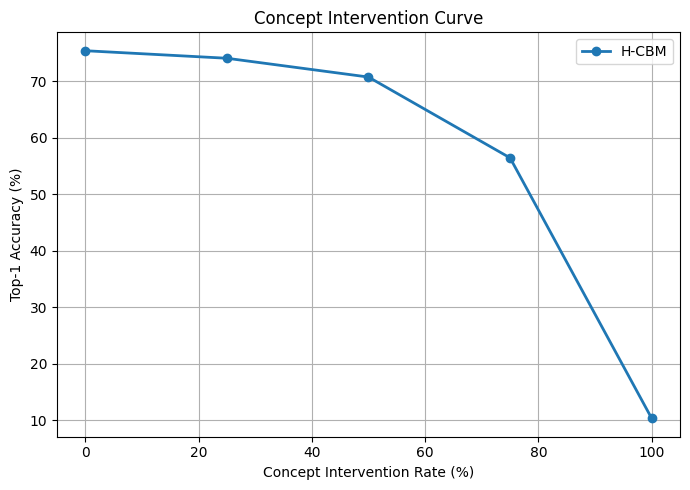

Saved concept_intervention.png


In [ ]:
@torch.no_grad()
def concept_intervention(model, loader, device, rate, n_runs=3):
    """
    Intervene on `rate` fraction of L1 concept groups by replacing
    their L2 attribute predictions with ground-truth values.
    Average accuracy over n_runs with different random group selections.
    """
    n_groups    = len(CONCEPT_NAMES)
    n_intervene = int(n_groups * rate)
    accs = []

    for run in range(n_runs):
        torch.manual_seed(run)
        correct, total = 0, 0

        for imgs, labels, l1, l2, cert, vis in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            l2 = l2.to(device)

            _, z_c, p_c, z_f, p_f = model(imgs)
            p_f_int = p_f.clone()

            # Randomly select which L1 groups to intervene
            selected = torch.randperm(n_groups)[:n_intervene].tolist()
            for g in selected:
                part_name = CONCEPT_NAMES[g]
                idxs      = part_to_attr_indices.get(part_name, [])
                if idxs:
                    p_f_int[:, idxs] = l2[:, idxs]

            out      = model.classifier(p_f_int)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)

        accs.append(correct / total)

    return float(np.mean(accs))


intervention_rates = [0.0, 0.25, 0.50, 0.75, 1.0]
hcbm_interv_accs  = []

print('Running concept intervention experiment...')
for rate in intervention_rates:
    acc = concept_intervention(model_hcbm, test_loader, device, rate)
    hcbm_interv_accs.append(acc)
    print(f'  Intervention {int(rate*100):3d}%: acc = {acc:.4f} ({acc*100:.1f}%)')

# Plot
plt.figure(figsize=(7, 5))
plt.plot([r*100 for r in intervention_rates], [a*100 for a in hcbm_interv_accs],
         marker='o', linewidth=2, label='H-CBM')
plt.xlabel('Concept Intervention Rate (%)')
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Concept Intervention Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/concept_intervention.png', dpi=150)
plt.show()
print('Saved concept_intervention.png')

## 8. Semantic Mistake Severity

Based on Bertinetto et al. CVPR 2020 — *Making Better Mistakes*.

For each misclassified image, we check whether the predicted species is from the **same bird family**
as the true species (mild mistake) or a different family (severe mistake).
Family membership is extracted from the CUB species names (e.g., `Black_footed_Albatross` → `albatross`).

A model making more **mild mistakes** is semantically more aligned with the taxonomy.

In [ ]:
# Load CUB class names  (e.g., '001.Black_footed_Albatross')
with open(os.path.join(DATASET_DIR, 'classes.txt')) as f:
    raw_class_lines = [line.strip().split(' ', 1)[1] for line in f]
class_names_cub = [c.split('.', 1)[1] for c in raw_class_lines]  # 'Black_footed_Albatross'

FAMILIES = [
    'albatross','fulmar','petrel','shearwater','gannet','cormorant','anhinga',
    'frigatebird','heron','egret','bittern','ibis','stork','pelican','booby',
    'duck','goose','swan','mallard','teal','merganser','scaup','scoter','eider',
    'bufflehead','goldeneye','osprey','hawk','eagle','kite','harrier','falcon',
    'kestrel','merlin','rail','coot','crane','sandpiper','plover','turnstone',
    'dunlin','snipe','dowitcher','godwit','curlew','willet','yellowlegs','phalarope',
    'gull','tern','skimmer','auklet','puffin','guillemot','murre','dovekie',
    'pigeon','dove','ani','cuckoo','roadrunner','hummingbird','swift','nighthawk',
    'kingfisher','woodpecker','flicker','sapsucker','flycatcher','kingbird',
    'pewee','phoebe','swallow','martin','jay','crow','raven','magpie','nutcracker',
    'chickadee','titmouse','nuthatch','creeper','wren','gnatcatcher','kinglet',
    'thrush','robin','bluebird','mockingbird','catbird','thrasher','starling',
    'waxwing','shrike','vireo','warbler','redstart','ovenbird','waterthrush',
    'sparrow','bunting','towhee','junco','longspur','tanager','cardinal','grosbeak',
    'blackbird','grackle','cowbird','oriole','meadowlark','finch','crossbill',
    'goldfinch','siskin','redpoll','dickcissel',
]

def get_family(class_name):
    words = class_name.lower().split('_')
    for w in words:
        if w in FAMILIES:
            return w
    return words[-1]  # fallback: last word

class_families = {i: get_family(class_names_cub[i]) for i in range(len(class_names_cub))}

def mistake_severity(true_cls, pred_cls):
    """1 = mild (same family), 2 = severe (different family)."""
    return 1 if class_families[true_cls] == class_families[pred_cls] else 2


@torch.no_grad()
def compute_severity(model, loader, device):
    model.eval()
    sev_list = []
    for imgs, labels, *rest in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out    = model(imgs)
        preds  = (out[0] if isinstance(out, tuple) else out).argmax(1)
        for t, p in zip(labels.cpu().tolist(), preds.cpu().tolist()):
            if t != p:
                sev_list.append(mistake_severity(t, p))
    if not sev_list:
        return {'mild_pct': 100.0, 'n_mistakes': 0}
    mild = sum(1 for s in sev_list if s == 1)
    return {
        'mild_pct':  mild / len(sev_list) * 100,
        'severe_pct': (len(sev_list) - mild) / len(sev_list) * 100,
        'n_mistakes': len(sev_list),
    }


sev_hcbm = compute_severity(model_hcbm, test_loader, device)
print(f'H-CBM Semantic Mistake Severity:')
print(f'  Mild mistakes  (same family): {sev_hcbm["mild_pct"]:.1f}%')
print(f'  Severe mistakes (diff family): {sev_hcbm["severe_pct"]:.1f}%')
print(f'  Total mistakes: {sev_hcbm["n_mistakes"]}')

H-CBM Semantic Mistake Severity:
  Mild mistakes  (same family): 46.8%
  Severe mistakes (diff family): 53.2%
  Total mistakes: 1424


## 9. Multi-Level Explanation Analysis

For selected test images, compare concept activations at L1 (coarse body parts) and L2 (fine attributes).
This shows the hierarchical explanation: which parts are active, and which specific attributes within those parts.

Also compare average concept activation between **correctly** and **incorrectly** classified images.

Collected 5 sample explanations


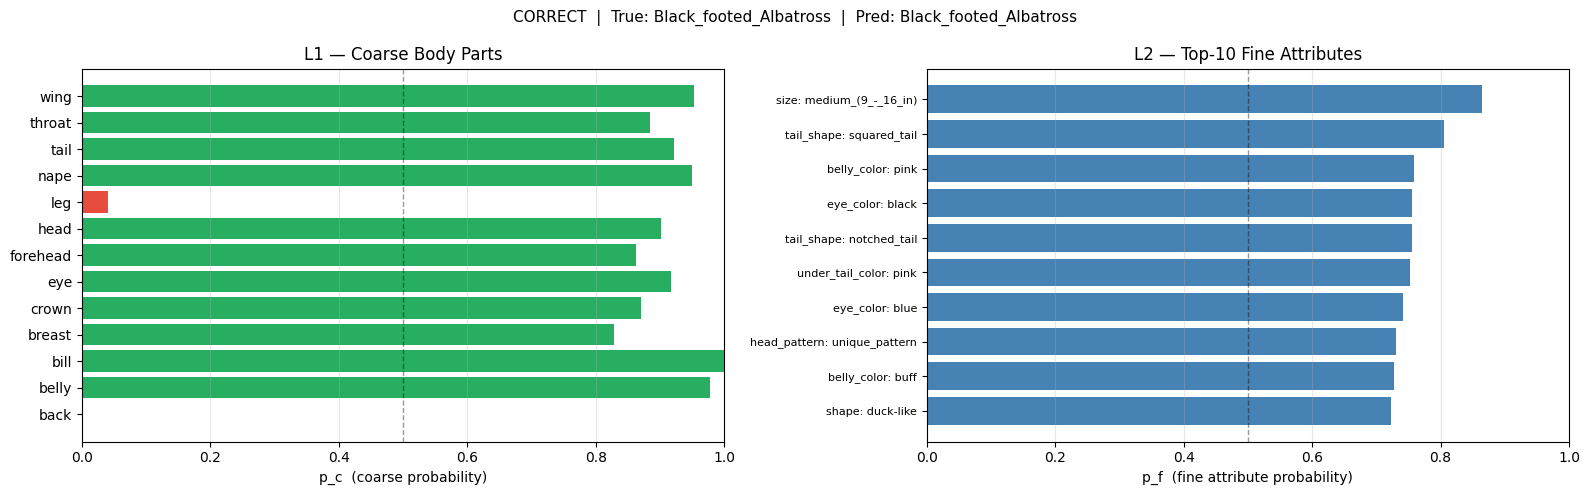

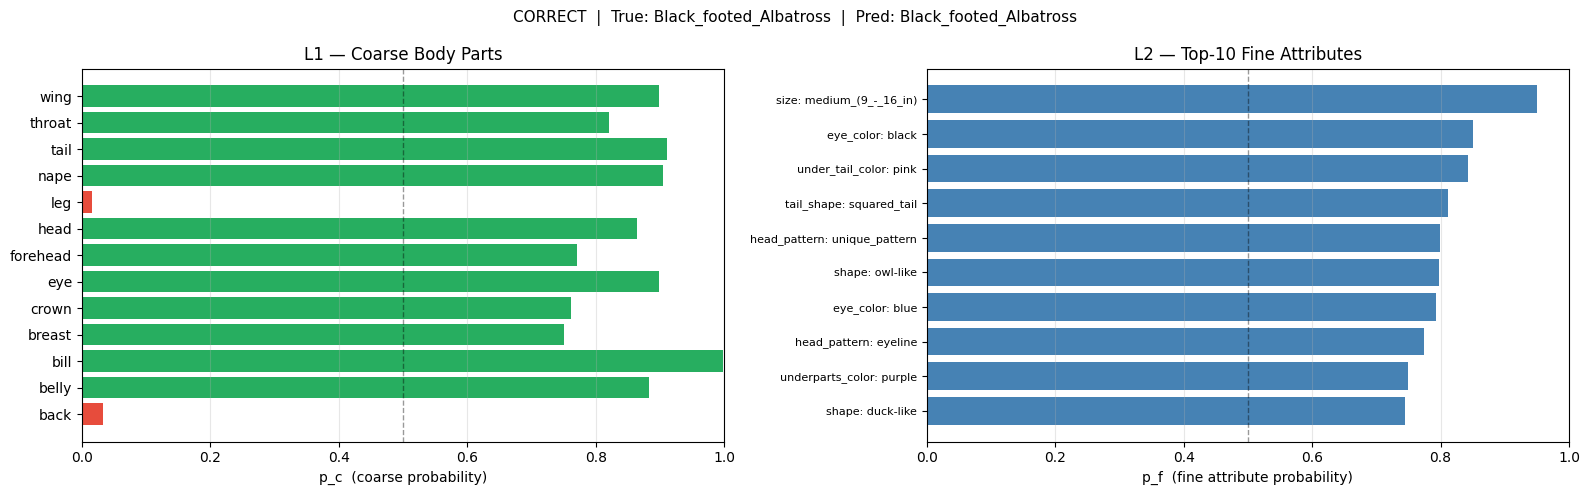

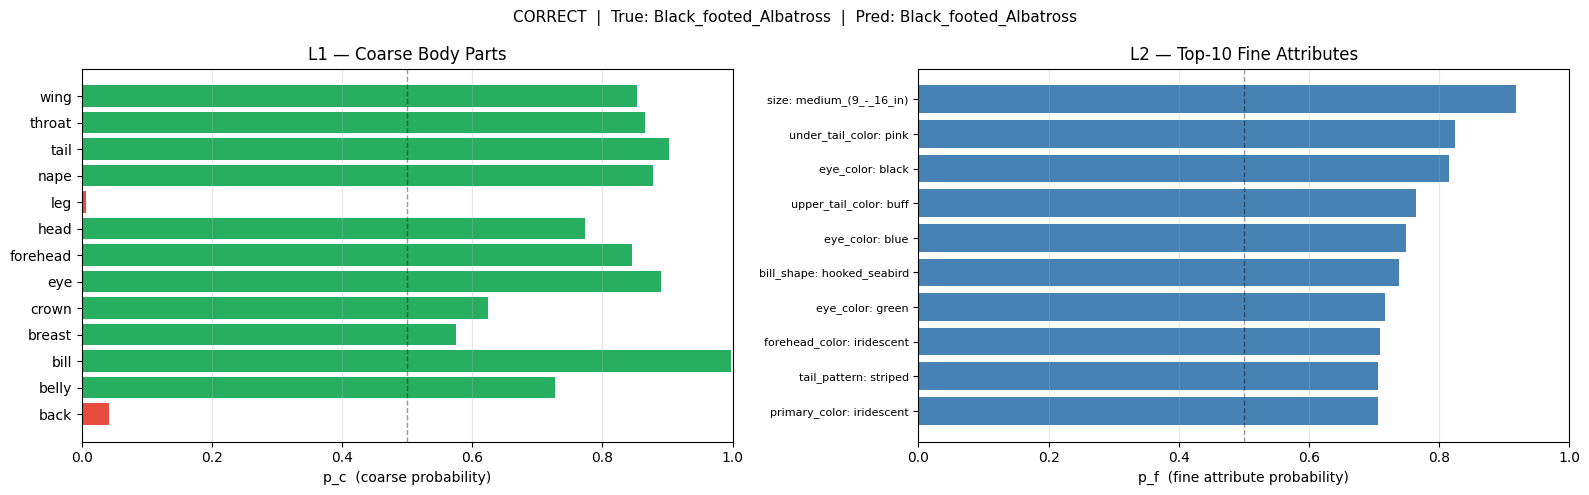

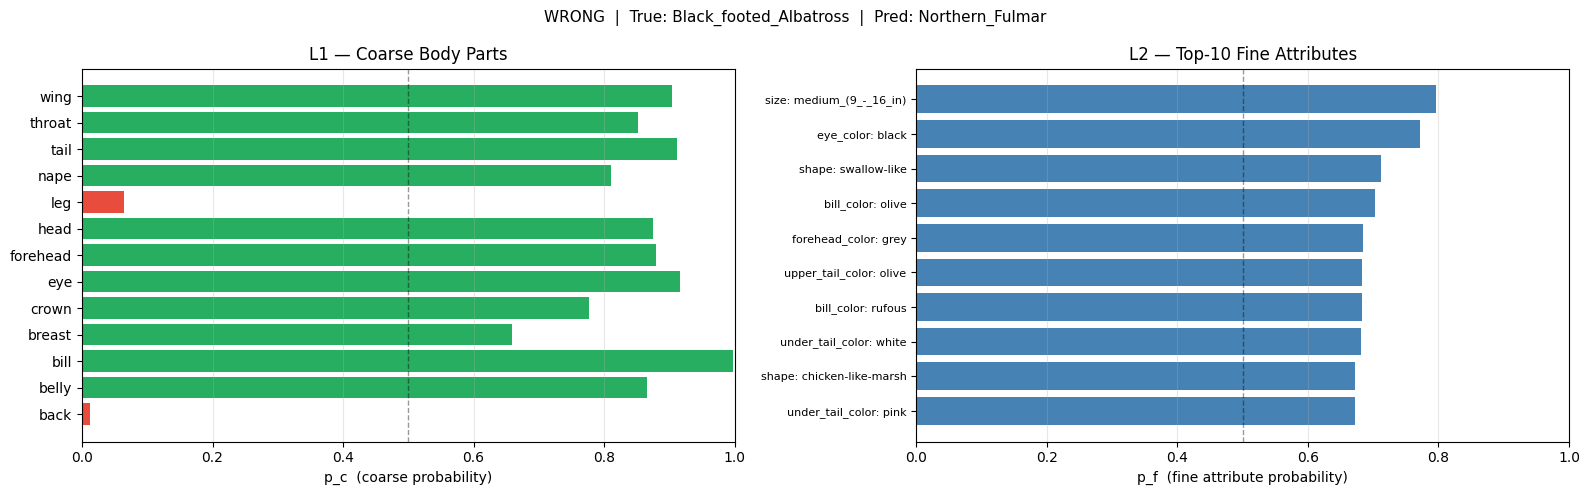

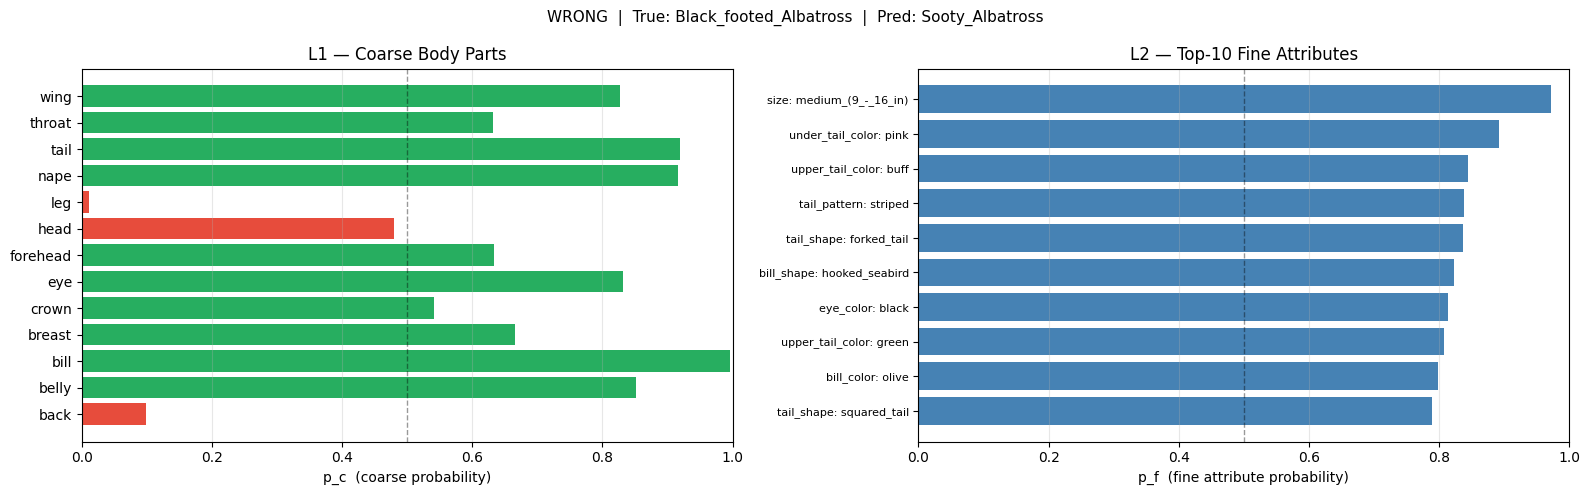

In [ ]:
@torch.no_grad()
def get_samples(model, loader, device, n_correct=3, n_wrong=2):
    """Collect a few correct and incorrect predictions with their concept activations."""
    model.eval()
    correct_samples, wrong_samples = [], []
    for imgs, labels, l1, l2, cert, vis in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        cls_out, _, p_c, _, p_f = model(imgs)
        preds = cls_out.argmax(1)
        for i in range(len(labels)):
            sample = {
                'label':   labels[i].item(),
                'pred':    preds[i].item(),
                'p_c':     p_c[i].cpu().numpy(),
                'p_f':     p_f[i].cpu().numpy(),
                'correct': (labels[i] == preds[i]).item(),
            }
            if sample['correct'] and len(correct_samples) < n_correct:
                correct_samples.append(sample)
            elif not sample['correct'] and len(wrong_samples) < n_wrong:
                wrong_samples.append(sample)
            if len(correct_samples) >= n_correct and len(wrong_samples) >= n_wrong:
                return correct_samples + wrong_samples
    return correct_samples + wrong_samples


def plot_multilevel_explanation(sample, concept_names, attr_names, top_k=10):
    status = 'CORRECT' if sample['correct'] else 'WRONG'
    title  = (f'{status}  |  True: {class_names_cub[sample["label"]]}'
              f'  |  Pred: {class_names_cub[sample["pred"]]}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=11)

    # L1 coarse: all 13 parts
    ax = axes[0]
    vals  = sample['p_c']
    colors = ['#27ae60' if v > 0.5 else '#e74c3c' for v in vals]
    ax.barh(concept_names, vals, color=colors)
    ax.axvline(0.5, linestyle='--', color='black', alpha=0.4, linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_xlabel('p_c  (coarse probability)')
    ax.set_title('L1 — Coarse Body Parts')
    ax.grid(axis='x', alpha=0.3)

    # L2 fine: top-k activated attributes
    ax = axes[1]
    top_idx  = np.argsort(sample['p_f'])[-top_k:][::-1]
    top_vals = sample['p_f'][top_idx]
    top_lbl  = [attr_names[i].replace('has_', '').replace('::', ': ')[:35] for i in top_idx]
    ax.barh(range(top_k), top_vals[::-1], color='steelblue')
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_lbl[::-1], fontsize=8)
    ax.axvline(0.5, linestyle='--', color='black', alpha=0.4, linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_xlabel('p_f  (fine attribute probability)')
    ax.set_title(f'L2 — Top-{top_k} Fine Attributes')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


samples = get_samples(model_hcbm, test_loader, device)
print(f'Collected {len(samples)} sample explanations')
for s in samples:
    plot_multilevel_explanation(s, CONCEPT_NAMES, attr_names)

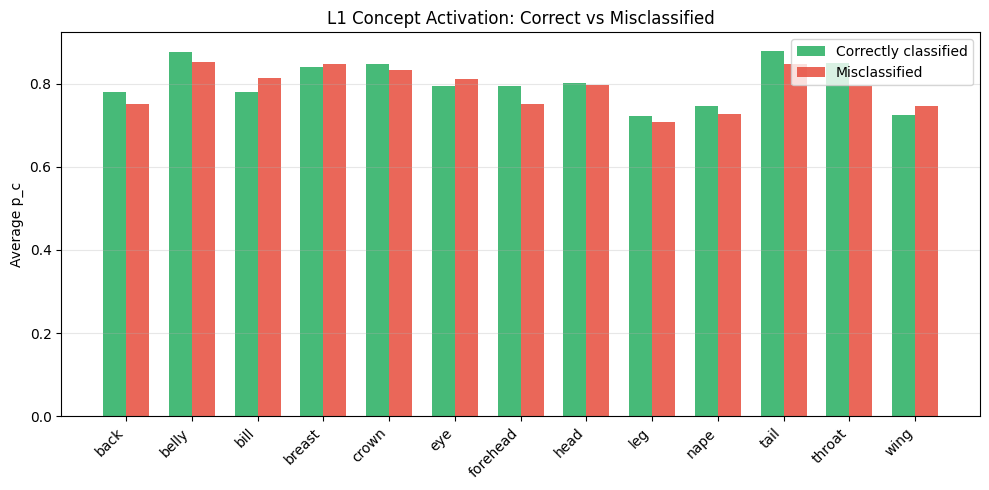

In [ ]:
# ── Average concept activation: correct vs incorrect predictions ────────────
@torch.no_grad()
def avg_concept_activations(model, loader, device):
    model.eval()
    pc_correct, pc_wrong = [], []
    for imgs, labels, *rest in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        cls_out, _, p_c, _, _ = model(imgs)
        preds = cls_out.argmax(1)
        correct_mask = (preds == labels).cpu().numpy()
        pc_np = p_c.cpu().numpy()
        pc_correct.append(pc_np[correct_mask])
        pc_wrong.append(pc_np[~correct_mask])
    pc_correct = np.vstack([x for x in pc_correct if len(x)])
    pc_wrong   = np.vstack([x for x in pc_wrong   if len(x)])
    return pc_correct.mean(axis=0), pc_wrong.mean(axis=0)


avg_correct, avg_wrong = avg_concept_activations(model_hcbm, test_loader, device)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_L1)
w = 0.35
ax.bar(x - w/2, avg_correct, w, label='Correctly classified', color='#27ae60', alpha=0.85)
ax.bar(x + w/2, avg_wrong,   w, label='Misclassified',        color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CONCEPT_NAMES, rotation=45, ha='right')
ax.set_ylabel('Average p_c')
ax.set_title('L1 Concept Activation: Correct vs Misclassified')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/concept_activation_comparison.png', dpi=150)
plt.show()

## 10. Baselines

Two baselines required for comparison:

| Baseline | Architecture | Concept levels | Training |
|----------|-------------|----------------|----------|
| **B1** ResNet-50 | Standard classifier (no concepts) | None | CrossEntropy only |
| **B2** Flat CBM  | Feature → L2 attributes → species | L2 only | L_fine + L_task |

Checkpoints are cached to Drive. Training only runs if the checkpoint does not exist.

In [ ]:
class ResNet50Baseline(nn.Module):
    """B1: End-to-end ResNet-50, no concept bottleneck."""
    def __init__(self, num_classes=200):
        super().__init__()
        backbone    = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Linear(2048, num_classes)
        self.net    = backbone

    def forward(self, x):
        return self.net(x)


class FlatCBM(nn.Module):
    """B2: Flat CBM (Koh et al. 2020) — no L1 hierarchy, no masking."""
    def __init__(self, num_classes=200, num_l2=312):
        super().__init__()
        backbone      = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.fine_head = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_l2)
        )
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        feats = self.features(x).flatten(1)
        z_f   = self.fine_head(feats)
        p_f   = torch.sigmoid(z_f)
        return self.classifier(p_f), z_f, p_f


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma

    def forward(self, logits, targets, mask=None):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        loss    = alpha_t * (1.0 - p_t) ** self.gamma * bce
        if mask is not None:
            loss = loss * mask
            return loss.sum() / mask.sum().clamp(min=1.0)
        return loss.mean()


focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
print('Baseline classes and FocalLoss defined.')

Baseline classes and FocalLoss defined.


In [ ]:
import os

# ── Train B1: ResNet-50 end-to-end (skip if checkpoint exists) ─────────────
def train_rn50(model, train_loader, val_loader, device, ckpt_path, n_epochs=30):
    opt = torch.optim.AdamW(
        [{'params': [p for n,p in model.net.named_parameters() if 'fc' not in n], 'lr': 1e-4},
         {'params': model.net.fc.parameters(), 'lr': 1e-3}],
        weight_decay=1e-4
    )
    sched    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val = float('inf')

    for ep in range(1, n_epochs + 1):
        model.train()
        for imgs, labels, *_ in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            F.cross_entropy(model(imgs), labels).backward()
            opt.step()

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels, *_ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vl += F.cross_entropy(out, labels).item() * labels.size(0)
                vc += (out.argmax(1) == labels).sum().item()
                vt += labels.size(0)
        vl /= vt
        sched.step(vl)
        if vl < best_val:
            best_val = vl
            torch.save({'model_state_dict': model.state_dict(),
                        'epoch': ep, 'val_loss': vl, 'val_acc': vc/vt}, ckpt_path)
        if ep % 5 == 0:
            print(f'  Ep {ep:3d}/{n_epochs} | val_loss={vl:.4f}  val_acc={vc/vt:.3f}')
    print(f'B1 training complete. Best val_loss={best_val:.4f}')


if not os.path.exists(B1_CKPT):
    if device.type == 'cpu':
        print('WARNING: No GPU detected. Skipping B1 baseline training.')
        print('Run this notebook in Colab with GPU to train baselines.')
        print(f'Expected checkpoint: {B1_CKPT}')
        model_b1 = None
    else:
        print('Training B1 — ResNet-50 baseline (30 epochs)...')
        model_b1 = ResNet50Baseline().to(device)
        train_rn50(model_b1, train_loader, val_loader, device, B1_CKPT)
else:
    print(f'B1 checkpoint found: {B1_CKPT} — skipping training.')
    model_b1 = None  # will be loaded in section 11


Training B1 — ResNet-50 baseline (30 epochs)...
  Ep  10 | val_loss=1.0312  val_acc=0.752
  Ep  20 | val_loss=1.1437  val_acc=0.758
  Ep  30 | val_loss=1.1266  val_acc=0.757
B1 training complete. Best val_loss=1.0171


In [ ]:
import os

# ── Train B2: Flat CBM (skip if checkpoint exists) ─────────────────────────
def train_flat_cbm(model, train_loader, val_loader, device, ckpt_path, n_epochs=50):
    opt = torch.optim.AdamW(
        [{'params': model.features.parameters(), 'lr': 1e-4},
         {'params': list(model.fine_head.parameters()) +
                    list(model.classifier.parameters()), 'lr': 1e-3}],
        weight_decay=1e-4
    )
    sched    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val = float('inf')

    for ep in range(1, n_epochs + 1):
        model.train()
        for imgs, labels, l1, l2, cert, vis in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            l2, cert     = l2.to(device), cert.to(device)
            opt.zero_grad()
            cls_out, z_f, p_f = model(imgs)
            (0.5 * focal_loss_fn(z_f, l2, mask=cert)
             + 1.0 * F.cross_entropy(cls_out, labels)).backward()
            opt.step()

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels, l1, l2, cert, vis in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                l2, cert     = l2.to(device), cert.to(device)
                cls_out, z_f, p_f = model(imgs)
                loss = (0.5 * focal_loss_fn(z_f, l2, mask=cert)
                        + 1.0 * F.cross_entropy(cls_out, labels))
                vl += loss.item() * labels.size(0)
                vc += (cls_out.argmax(1) == labels).sum().item()
                vt += labels.size(0)
        vl /= vt
        sched.step(vl)
        if vl < best_val:
            best_val = vl
            torch.save({'model_state_dict': model.state_dict(),
                        'epoch': ep, 'val_loss': vl, 'val_acc': vc/vt}, ckpt_path)
        if ep % 5 == 0:
            print(f'  Ep {ep:3d}/{n_epochs} | val_loss={vl:.4f}  val_acc={vc/vt:.3f}')
    print(f'B2 training complete. Best val_loss={best_val:.4f}')


if not os.path.exists(B2_CKPT):
    if device.type == 'cpu':
        print('WARNING: No GPU detected. Skipping B2 baseline training.')
        print('Run this notebook in Colab with GPU to train baselines.')
        print(f'Expected checkpoint: {B2_CKPT}')
        model_b2 = None
    else:
        print('Training B2 — Flat CBM baseline (50 epochs)...')
        model_b2 = FlatCBM(num_classes=200, num_l2=NUM_L2).to(device)
        train_flat_cbm(model_b2, train_loader, val_loader, device, B2_CKPT)
else:
    print(f'B2 checkpoint found: {B2_CKPT} — skipping training.')
    model_b2 = None  # will be loaded in section 11


NameError: name 'os' is not defined

## 11. Final Comparison Table

Load all model checkpoints and compute all metrics to produce the final comparison.

In [ ]:
# Load B1
ckpt_b1  = torch.load(B1_CKPT, map_location=device, weights_only=False)
model_b1 = ResNet50Baseline().to(device)
model_b1.load_state_dict(ckpt_b1['model_state_dict'])
model_b1.eval()
print(f'B1 loaded (epoch {ckpt_b1["epoch"]}, val_acc={ckpt_b1["val_acc"]:.3f})')

# Load B2
ckpt_b2  = torch.load(B2_CKPT, map_location=device, weights_only=False)
model_b2 = FlatCBM(num_classes=200, num_l2=NUM_L2).to(device)
model_b2.load_state_dict(ckpt_b2['model_state_dict'])
model_b2.eval()
print(f'B2 loaded (epoch {ckpt_b2["epoch"]}, val_acc={ckpt_b2["val_acc"]:.3f})')


In [ ]:
print('Evaluating B1 — ResNet-50...')
b1_top1, b1_top5 = compute_topk(model_b1, test_loader, device)
sev_b1           = compute_severity(model_b1, test_loader, device)

print('Evaluating B2 — Flat CBM...')
b2_top1, b2_top5 = compute_topk(model_b2, test_loader, device)
sev_b2           = compute_severity(model_b2, test_loader, device)

# L2 concept quality for B2
@torch.no_grad()
def collect_flat_preds(model, loader, device):
    model.eval()
    pf_list, l2_list = [], []
    for imgs, labels, l1, l2, cert, vis in loader:
        imgs = imgs.to(device)
        _, z_f, p_f = model(imgs)
        pf_list.append(p_f.cpu().numpy())
        l2_list.append(l2.numpy())
    return np.vstack(pf_list), np.vstack(l2_list)

b2_pf, b2_l2 = collect_flat_preds(model_b2, test_loader, device)
b2_l2_preds  = (b2_pf > 0.5).astype(int)
b2_f1_scores = [f1_score(b2_l2[:, j], b2_l2_preds[:, j], zero_division=0) for j in range(NUM_L2)]
b2_f1_macro  = float(np.mean(b2_f1_scores))
b2_auroc = [roc_auc_score(b2_l2[:, j], b2_pf[:, j])
            for j in range(NUM_L2) if len(np.unique(b2_l2[:, j])) > 1]
b2_auroc_macro = float(np.mean(b2_auroc)) if b2_auroc else 0.0

# Concept intervention for B2 (uses same function, but B2 has no p_c/p_f hierarchy)
# For Flat CBM we intervene directly on p_f (no parent masking)
@torch.no_grad()
def concept_intervention_flat(model, loader, device, rate, n_runs=3):
    n_groups    = len(CONCEPT_NAMES)
    n_intervene = int(n_groups * rate)
    accs = []
    for run in range(n_runs):
        torch.manual_seed(run)
        correct, total = 0, 0
        for imgs, labels, l1, l2, cert, vis in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            l2 = l2.to(device)
            cls_out, z_f, p_f = model(imgs)
            p_f_int = p_f.clone()
            selected = torch.randperm(n_groups)[:n_intervene].tolist()
            for g in selected:
                idxs = part_to_attr_indices.get(CONCEPT_NAMES[g], [])
                if idxs:
                    p_f_int[:, idxs] = l2[:, idxs]
            out      = model.classifier(p_f_int)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
        accs.append(correct / total)
    return float(np.mean(accs))

b2_interv_accs = [concept_intervention_flat(model_b2, test_loader, device, r)
                  for r in intervention_rates]

print('Baseline evaluation complete.')
print(f'  B1 Top-1: {b1_top1:.4f}, Top-5: {b1_top5:.4f}, Mild mistakes: {sev_b1["mild_pct"]:.1f}%')
print(f'  B2 Top-1: {b2_top1:.4f}, Top-5: {b2_top5:.4f}, L2 F1: {b2_f1_macro:.4f}, Mild: {sev_b2["mild_pct"]:.1f}%')

In [ ]:
# ── Final Comparison Table ────────────────────────────────────────────────────
table = {
    'Model':               ['ResNet-50 (B1)', 'Flat CBM (B2)', 'H-CBM (ours)'],
    'Top-1 Acc':           [f'{b1_top1:.3f}',   f'{b2_top1:.3f}',   f'{hcbm_top1:.3f}'],
    'Top-5 Acc':           [f'{b1_top5:.3f}',   f'{b2_top5:.3f}',   f'{hcbm_top5:.3f}'],
    'L1 Concept Acc':      ['—',                '—',                f'{l1_acc_macro:.3f}'],
    'L2 macro-F1':         ['—',                f'{b2_f1_macro:.3f}', f'{l2_f1_macro:.3f}'],
    'L2 macro-AUROC':      ['—',                f'{b2_auroc_macro:.3f}', f'{l2_auroc_macro:.3f}'],
    'Mild Mistake %':      [f'{sev_b1["mild_pct"]:.1f}%',
                            f'{sev_b2["mild_pct"]:.1f}%',
                            f'{sev_hcbm["mild_pct"]:.1f}%'],
    'Acc@0% Interv':       ['—',                f'{b2_interv_accs[0]:.3f}',  f'{hcbm_interv_accs[0]:.3f}'],
    'Acc@100% Interv':     ['—',                f'{b2_interv_accs[4]:.3f}',  f'{hcbm_interv_accs[4]:.3f}'],
}

df = pd.DataFrame(table)
print('\n' + '='*80)
print('FINAL COMPARISON TABLE')
print('='*80)
print(df.to_string(index=False))
print('='*80)

# Also update intervention plot with all models
plt.figure(figsize=(8, 5))
plt.plot([r*100 for r in intervention_rates], [a*100 for a in hcbm_interv_accs],
         marker='o', linewidth=2, label='H-CBM (ours)')
plt.plot([r*100 for r in intervention_rates], [a*100 for a in b2_interv_accs],
         marker='s', linewidth=2, linestyle='--', label='Flat CBM (B2)')
plt.xlabel('Concept Intervention Rate (%)')
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Concept Intervention: H-CBM vs Flat CBM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/concept_intervention_comparison.png', dpi=150)
plt.show()
print('\nAll results saved to Drive.')